In [4]:
# ── Recharger le modèle ───────────────────────────────────────
import tensorflow as tf

model_final = tf.keras.models.load_model('cnn2d_best_ov.keras')
print(f" Modèle chargé : {model_final.name}")
print(f"   Entrée : {model_final.input_shape}")
print(f"   Params : {model_final.count_params():,}")

 Modèle chargé : CNN2D_MelSpec
   Entrée : (None, 64, 51, 1)
   Params : 165,156


In [6]:
# ════════════════════════════════════════════════════════════════
# CONVERSION TFLITE — Float32, Float16, INT8
# ════════════════════════════════════════════════════════════════
import tensorflow as tf
import numpy as np
import time
import os
from pathlib import Path
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


OUTPUT_DIR = Path("C:/Users/asalou/S7/stages7/project/augmentation/aug")

# ── Dataset de calibration pour INT8 ─────────────────────────
# Recharger X_mel et créer le dataset représentatif
X_mel = np.load(f'{OUTPUT_DIR}/X_mel_ov.npy')
y_enc = np.load(f'{OUTPUT_DIR}/y_enc_ov.npy')
y_raw = np.load(f'{OUTPUT_DIR}/y_augmented_ov.npy', allow_pickle=True)



le    = LabelEncoder()
le.fit(y_raw)

_, X_temp, _, y_temp = train_test_split(
    X_mel, y_enc, test_size=0.30, stratify=y_enc, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f" Données chargées — Test : {X_test.shape}")
print(f"   Classes : {le.classes_}")

def representative_dataset():
    """200 échantillons pour calibrer les plages INT8."""
    for i in range(200):
        yield [X_test[i:i+1].astype(np.float32)]

 Données chargées — Test : (900, 64, 51, 1)
   Classes : ['bruit_ambiant' 'bruit_chasse' 'miction_active' 'silence']


In [7]:
# ── Conversion 3 versions ─────────────────────────────────────
conversions = {}

# Version 1 : Float32
print("1. Conversion Float32...")
conv_f32 = tf.lite.TFLiteConverter.from_keras_model(model_final)
tflite_f32 = conv_f32.convert()
path_f32 = f'{OUTPUT_DIR}/cnn2d_float32.tflite'
open(path_f32, 'wb').write(tflite_f32)
conversions['Float32'] = {'path': path_f32, 'bytes': len(tflite_f32)}
print(f"   {len(tflite_f32)/1024:.1f} KB")

# Version 2 : Float16
print("2. Conversion Float16...")
conv_f16 = tf.lite.TFLiteConverter.from_keras_model(model_final)
conv_f16.optimizations = [tf.lite.Optimize.DEFAULT]
conv_f16.target_spec.supported_types = [tf.float16]
tflite_f16 = conv_f16.convert()
path_f16 = f'{OUTPUT_DIR}/cnn2d_float16.tflite'
open(path_f16, 'wb').write(tflite_f16)
conversions['Float16'] = {'path': path_f16, 'bytes': len(tflite_f16)}
print(f"    {len(tflite_f16)/1024:.1f} KB")

# Version 3 : INT8
print("3. Conversion INT8 (calibration ~30s)...")
conv_int8 = tf.lite.TFLiteConverter.from_keras_model(model_final)
conv_int8.optimizations = [tf.lite.Optimize.DEFAULT]
conv_int8.representative_dataset = representative_dataset
conv_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv_int8.inference_input_type  = tf.int8
conv_int8.inference_output_type = tf.int8
tflite_int8 = conv_int8.convert()
path_int8 = f'{OUTPUT_DIR}/cnn2d_int8.tflite'
open(path_int8, 'wb').write(tflite_int8)
conversions['INT8'] = {'path': path_int8, 'bytes': len(tflite_int8)}
print(f"   {len(tflite_int8)/1024:.1f} KB")

# ── Résumé tailles ────────────────────────────────────────────
print("\n" + "="*50)
print("TAILLES DES MODÈLES")
print("="*50)
ref = conversions['Float32']['bytes']
for nom, info in conversions.items():
    ratio = ref / info['bytes']
    bar   = '█' * int(ratio * 5)
    print(f"  {nom:10s} : {info['bytes']/1024:7.1f} KB  "
          f"(÷{ratio:.1f})  {bar}")
print("="*50)

1. Conversion Float32...
INFO:tensorflow:Assets written to: C:\Users\asalou\AppData\Local\Temp\tmpm18vyurw\assets


INFO:tensorflow:Assets written to: C:\Users\asalou\AppData\Local\Temp\tmpm18vyurw\assets


Saved artifact at 'C:\Users\asalou\AppData\Local\Temp\tmpm18vyurw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 51, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  1943415818544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943414433472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943408812704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943408816048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1942856051952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943411566624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943408815168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943409206976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943409213136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943409199232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943409

INFO:tensorflow:Assets written to: C:\Users\asalou\AppData\Local\Temp\tmparxpspgk\assets


Saved artifact at 'C:\Users\asalou\AppData\Local\Temp\tmparxpspgk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 51, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  1943415818544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943414433472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943408812704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943408816048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1942856051952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943411566624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943408815168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943409206976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943409213136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943409199232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943409

INFO:tensorflow:Assets written to: C:\Users\asalou\AppData\Local\Temp\tmpxn5ng9te\assets


Saved artifact at 'C:\Users\asalou\AppData\Local\Temp\tmpxn5ng9te'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 51, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  1943415818544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943414433472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943408812704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943408816048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1942856051952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943411566624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943408815168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943409206976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943409213136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943409199232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1943409

C:\Users\asalou\S7\envs\stages7\lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


   183.8 KB

TAILLES DES MODÈLES
  Float32    :   651.1 KB  (÷1.0)  █████
  Float16    :   332.7 KB  (÷2.0)  █████████
  INT8       :   183.8 KB  (÷3.5)  █████████████████


In [8]:
# ════════════════════════════════════════════════════════════════
# BENCHMARK — Précision + Vitesse sur test set
# ════════════════════════════════════════════════════════════════

def benchmark_tflite(path, X_test_data, y_test_data, nom):
    interpreter = tf.lite.Interpreter(model_path=path)
    interpreter.allocate_tensors()

    inp  = interpreter.get_input_details()[0]
    out  = interpreter.get_output_details()[0]
    i_scale, i_zp = inp.get('quantization',  (1.0, 0))
    o_scale, o_zp = out.get('quantization',  (1.0, 0))

    y_pred  = []
    t_total = 0

    for i in range(len(X_test_data)):
        sample = X_test_data[i:i+1].astype(np.float32)

        # Quantifier si INT8
        if inp['dtype'] == np.int8:
            sample = np.clip(
                sample / i_scale + i_zp, -128, 127
            ).astype(np.int8)

        interpreter.set_tensor(inp['index'], sample)
        t0 = time.perf_counter()
        interpreter.invoke()
        t_total += time.perf_counter() - t0

        output = interpreter.get_tensor(out['index'])

        # Déquantifier si INT8
        if out['dtype'] == np.int8:
            output = (output.astype(np.float32) - o_zp) * o_scale

        y_pred.append(np.argmax(output))

    y_pred = np.array(y_pred)
    return {
        'nom':      nom,
        'accuracy': accuracy_score(y_test_data, y_pred),
        'bal_acc':  balanced_accuracy_score(y_test_data, y_pred),
        'temps_ms': (t_total / len(X_test_data)) * 1000,
        'y_pred':   y_pred
    }

# ── Lancer benchmark ──────────────────────────────────────────
print("Benchmark en cours...")
resultats = {}
for nom, info in conversions.items():
    res = benchmark_tflite(info['path'], X_test, y_test, nom)
    resultats[nom] = res
    print(f"  ✅ {nom} terminé")

# ── Tableau comparatif ────────────────────────────────────────
print("\n" + "="*75)
print("BENCHMARK TFLITE — Float32 vs Float16 vs INT8")
print("="*75)
print(f"{'Modèle':12s} | {'Taille':>8} | {'Accuracy':>9} | "
      f"{'Bal.Acc':>8} | {'t/inf':>8} | {'Perte Bal.':>10}")
print("-"*75)

ref_bal = resultats['Float32']['bal_acc']
for nom, res in resultats.items():
    taille = conversions[nom]['bytes'] / 1024
    perte  = res['bal_acc'] - ref_bal
    print(f"{nom:12s} | {taille:7.1f}KB | {res['accuracy']:9.3f} | "
          f"{res['bal_acc']:8.3f} | {res['temps_ms']:6.2f}ms | {perte:+10.3f}")

print("="*75)
print(f"\nModèle Keras original : Bal.Acc ≈ 0.877")

# ── Rapport détaillé INT8 ─────────────────────────────────────
print(f"\nRapport détaillé INT8 :")
print(classification_report(
    y_test, resultats['INT8']['y_pred'],
    target_names=le.classes_, digits=3))

Benchmark en cours...


C:\Users\asalou\S7\envs\stages7\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  ✅ Float32 terminé


C:\Users\asalou\S7\envs\stages7\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  ✅ Float16 terminé


C:\Users\asalou\S7\envs\stages7\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  ✅ INT8 terminé

BENCHMARK TFLITE — Float32 vs Float16 vs INT8
Modèle       |   Taille |  Accuracy |  Bal.Acc |    t/inf | Perte Bal.
---------------------------------------------------------------------------
Float32      |   651.1KB |     0.892 |    0.892 |   2.14ms |     +0.000
Float16      |   332.7KB |     0.890 |    0.890 |   2.68ms |     -0.002
INT8         |   183.8KB |     0.882 |    0.882 |   3.93ms |     -0.010

Modèle Keras original : Bal.Acc ≈ 0.877

Rapport détaillé INT8 :
                precision    recall  f1-score   support

 bruit_ambiant      0.811     0.818     0.814       225
  bruit_chasse      0.938     0.942     0.940       225
miction_active      0.985     0.880     0.930       225
       silence      0.813     0.889     0.849       225

      accuracy                          0.882       900
     macro avg      0.887     0.882     0.883       900
  weighted avg      0.887     0.882     0.883       900



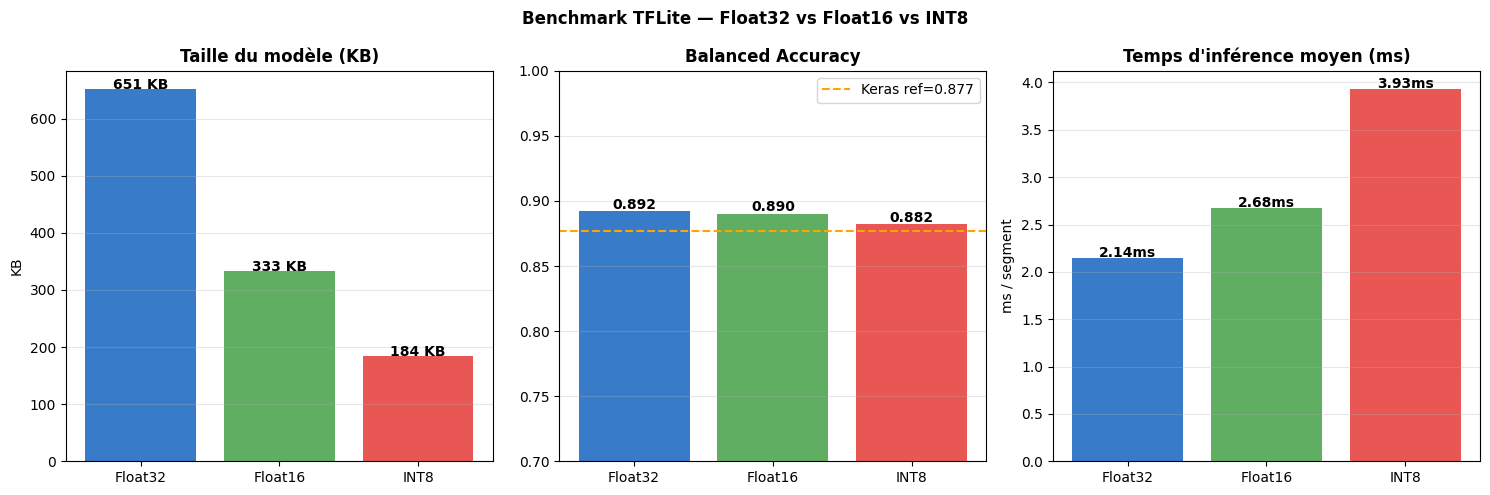


✅ Modèles TFLite sauvegardés :
   Float32    → C:\Users\asalou\S7\stages7\project\augmentation\aug/cnn2d_float32.tflite  (651.1 KB)
   Float16    → C:\Users\asalou\S7\stages7\project\augmentation\aug/cnn2d_float16.tflite  (332.7 KB)
   INT8       → C:\Users\asalou\S7\stages7\project\augmentation\aug/cnn2d_int8.tflite  (183.8 KB)

→ Modèle recommandé pour embarqué : cnn2d_int8.tflite


In [9]:
# ── Visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Benchmark TFLite — Float32 vs Float16 vs INT8',
             fontweight='bold', fontsize=12)

noms    = list(resultats.keys())
tailles = [conversions[n]['bytes']/1024 for n in noms]
bals    = [resultats[n]['bal_acc']  for n in noms]
temps   = [resultats[n]['temps_ms'] for n in noms]
colors  = ['#1565C0', '#43A047', '#E53935']

# Tailles
axes[0].bar(noms, tailles, color=colors, alpha=0.85)
axes[0].set_title('Taille du modèle (KB)', fontweight='bold')
axes[0].set_ylabel('KB')
for i, v in enumerate(tailles):
    axes[0].text(i, v+0.5, f'{v:.0f} KB', ha='center', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Balanced Accuracy
axes[1].bar(noms, bals, color=colors, alpha=0.85)
axes[1].axhline(0.877, color='orange', ls='--', lw=1.5, label='Keras ref=0.877')
axes[1].set_title('Balanced Accuracy', fontweight='bold')
axes[1].set_ylim(0.7, 1.0)
for i, v in enumerate(bals):
    axes[1].text(i, v+0.002, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Temps
axes[2].bar(noms, temps, color=colors, alpha=0.85)
axes[2].set_title('Temps d\'inférence moyen (ms)', fontweight='bold')
axes[2].set_ylabel('ms / segment')
for i, v in enumerate(temps):
    axes[2].text(i, v+0.01, f'{v:.2f}ms', ha='center', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/benchmark_tflite.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Sauvegarder le modèle INT8 ────────────────────────────────
print(f"\n✅ Modèles TFLite sauvegardés :")
for nom, info in conversions.items():
    print(f"   {nom:10s} → {info['path']}  ({info['bytes']/1024:.1f} KB)")
print(f"\n→ Modèle recommandé pour embarqué : cnn2d_int8.tflite")


In [11]:
# ── Afficher les métriques embarquées ────────────────────────

# 1. Nombre de paramètres
total_params    = model_final.count_params()
trainable       = sum([tf.size(w).numpy() for w in model_final.trainable_weights])
non_trainable   = sum([tf.size(w).numpy() for w in model_final.non_trainable_weights])

print("="*55)
print("MÉTRIQUES EMBARQUÉES DU MODÈLE CNN 2D")
print("="*55)
print(f"\n1. PARAMÈTRES (les 'points' du modèle)")
print(f"   Total           : {total_params:>10,}")
print(f"   Entraînables    : {trainable:>10,}  ← poids des couches Conv + Dense")
print(f"   Non entraîn.    : {non_trainable:>10,}  ← BatchNormalization")

print(f"\n2. MÉMOIRE NÉCESSAIRE")
print(f"   Float32 (32 bits) : {total_params*4/1024:>8.1f} KB")
print(f"   Float16 (16 bits) : {total_params*2/1024:>8.1f} KB")
print(f"   INT8    ( 8 bits) : {total_params*1/1024:>8.1f} KB")

print(f"\n3. OPÉRATIONS PAR INFÉRENCE (MACs)")
# ── Version corrigée du calcul MACs ──────────────────────────
macs_total = 0
print(f"\n3. OPÉRATIONS PAR INFÉRENCE (MACs)")
print(f"   {'Couche':30s} | {'Paramètres':>12} | {'MACs':>12}")
print("   " + "-"*60)

for layer in model_final.layers:
    if 'conv2d' in layer.name and layer.get_weights():
        w      = layer.get_weights()[0]   # (kH, kW, in_ch, out_ch)
        kH, kW = w.shape[0], w.shape[1]
        in_ch  = w.shape[2]
        out_ch = w.shape[3]
        
        # Récupérer la forme de sortie depuis la config
        out = layer.output
        H_out = out.shape[1] if out.shape[1] else 1
        W_out = out.shape[2] if out.shape[2] else 1
        
        params = layer.count_params()
        macs   = kH * kW * in_ch * out_ch * H_out * W_out
        macs_total += macs
        print(f"   {layer.name:30s} | {params:>12,} | {macs:>12,}")

print("   " + "-"*60)
print(f"   {'TOTAL':30s} | {model_final.count_params():>12,} | {macs_total:>12,}")
print(f"   soit {macs_total/1e6:.2f} MMACs (millions d'opérations)")

MÉTRIQUES EMBARQUÉES DU MODÈLE CNN 2D

1. PARAMÈTRES (les 'points' du modèle)
   Total           :    165,156
   Entraînables    :    164,516  ← poids des couches Conv + Dense
   Non entraîn.    :        640  ← BatchNormalization

2. MÉMOIRE NÉCESSAIRE
   Float32 (32 bits) :    645.1 KB
   Float16 (16 bits) :    322.6 KB
   INT8    ( 8 bits) :    161.3 KB

3. OPÉRATIONS PAR INFÉRENCE (MACs)

3. OPÉRATIONS PAR INFÉRENCE (MACs)
   Couche                         |   Paramètres |         MACs
   ------------------------------------------------------------
   conv2d                         |          320 |      940,032
   conv2d_1                       |        9,248 |   30,081,024
   conv2d_2                       |       18,496 |   14,745,600
   conv2d_3                       |       36,928 |   29,491,200
   conv2d_4                       |       73,856 |   14,155,776
   ------------------------------------------------------------
   TOTAL                          |      165,156 |   89,41